In [4]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

In [8]:
#loading the datasets
training_path = r'C:\\Users\\GIGABYTE\\Desktop\\drug-sentiment-analysis\\data\\raw\\train_F3WbcTw_1icmK82.csv'
test_path = r'C:\\Users\\GIGABYTE\\Desktop\\drug-sentiment-analysis\\data\\raw\\test_tOlRoBf_VeRQtHl.csv'
training_data = pd.read_csv(training_path)
test_data = pd.read_csv(test_path)

In [9]:
#see first 5 rows of dataset
training_data.head()

,unique_hash,text,drug,sentiment
0,2e180be4c9214c1f5ab51fd8cc32bc80c9f612e0,Autoimmune diseases tend to come in clusters. ...,gilenya,2
1,9eba8f80e7e20f3a2f48685530748fbfa95943e4,I can completely understand why you’d want to ...,gilenya,2
2,fe809672251f6bd0d986e00380f48d047c7e7b76,Interesting that it only targets S1P-1/5 recep...,fingolimod,2
3,bd22104dfa9ec80db4099523e03fae7a52735eb6,"Very interesting, grand merci. Now I wonder wh...",ocrevus,2
4,b227688381f9b25e5b65109dd00f7f895e838249,"Hi everybody, My latest MRI results for Brain ...",gilenya,1


In [ ]:
#checking the shape of the datasets
print('training data shape:', training_data.shape)
print('test data shape:', test_data.shape)

training data shape: (5279, 4)
test data shape: (2924, 3)


In [15]:
#info about the dataset
training_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5279 entries, 0 to 5278
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   unique_hash  5279 non-null   object
 1   text         5279 non-null   object
 2   drug         5279 non-null   object
 3   sentiment    5279 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 165.1+ KB


In [17]:
#checking for missing values
training_data.isnull().sum()

unique_hash    0
text           0
drug           0
sentiment      0
dtype: int64

In [12]:
#value counts of target variable
training_data['sentiment'].value_counts()

sentiment
2    3825
1     837
0     617
Name: count, dtype: int64

we have imbalanced target data

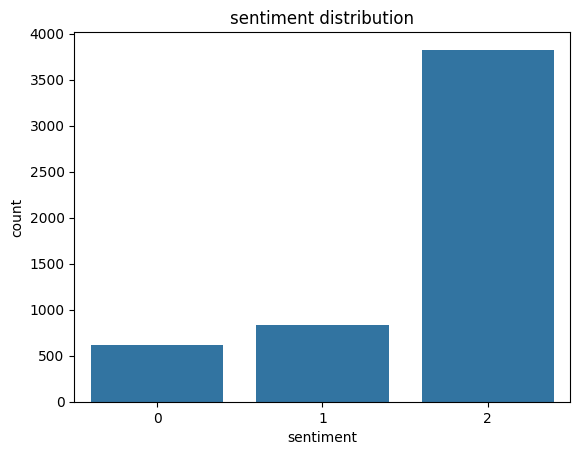

In [14]:
#ploting the distribution of target variable
sns.countplot(x='sentiment', data=training_data)
plt.title('sentiment distribution');

In [19]:
#checking drugs mentioned
training_data["drug"].value_counts().head(10)

drug
ocrevus        676
gilenya        666
ocrelizumab    441
entyvio        303
humira         270
fingolimod     238
remicade       229
opdivo         224
tarceva        218
cladribine     200
Name: count, dtype: int64

In [23]:
training_data["drug"].value_counts().tail(10)

drug
brigatinib     1
pegaptanib     1
alemtuzumab    1
rhumab 2h7     1
filgotinib     1
alectnib       1
crizotnib      1
ct-p13         1
guselkumab     1
cyramza        1
Name: count, dtype: int64

In [24]:
training_data["drug"].nunique()

102

In [22]:
training_data.sample(5)['text'].values

array(["My husband (age 25, a non smoker and non alcoholic) has been diagnosed with NSCLC for 5 months. When was diaggonisrd the primary tumor size was 8.2 cm * 5.0 cm in left lung with multiple nodules in both lung and mild plural effusion. According the biopsy he is having stage lV adinocarcinoma and unfortunately both EGFR and ALK mutations came negative. Still waiting for ROS1 mutation result. As the first line treatment he has taken four cycles of chemotherapy with pemetrexed and carbo every three weeks. After 4 cycles CT reveals the tumor have shirnked to 3.7 cm * 2.8 cm and nodules is still present. Now he is on pemetrexed maintenance and taken four cycle of it and his next CT is on 5th of November. He taking treatment at Tata Memorial Hospital, Mumbai, India. I'm anxious about his next treatment. Now we are thinking about two options. 1. CimaVax/ Vaxira treatment in Cuba: I've contacted to La Predira Hospital, Havana and sent all the medical documents. They have replied that my

In [25]:
training_data['text'][0]

'Autoimmune diseases tend to come in clusters. As for Gilenya – if you feel good, don’t think about it, it won’t change anything but waste your time and energy. I’m taking Tysabri and feel amazing, no symptoms (other than dodgy color vision, but I’ve had it since always, so, don’t know) and I don’t know if it will last a month, a year, a decade, ive just decided to enjoy the ride, no point in worrying.'

In [ ]:
#checking for duplicates
training_data.duplicated().sum()

np.int64(0)

In [45]:
training_data.groupby('drug')['sentiment'].value_counts().unstack().fillna(0).div(training_data.groupby('drug')['sentiment'].value_counts().unstack().fillna(0).sum(axis=1), axis=0).head(20)

sentiment,0,1,2
drug,,,
afatinib,0.100000,0.100000,0.800000
aflibercept,0.000000,0.000000,1.000000
alecensa,0.300000,0.000000,0.700000
alectinib,0.255814,0.069767,0.674419
alectnib,0.000000,0.000000,1.000000
alemtuzumab,0.000000,0.000000,1.000000
alimta,0.075342,0.130137,0.794521
almita,0.500000,0.000000,0.500000
alunbrig,0.000000,1.000000,0.000000


<Axes: xlabel='drug'>

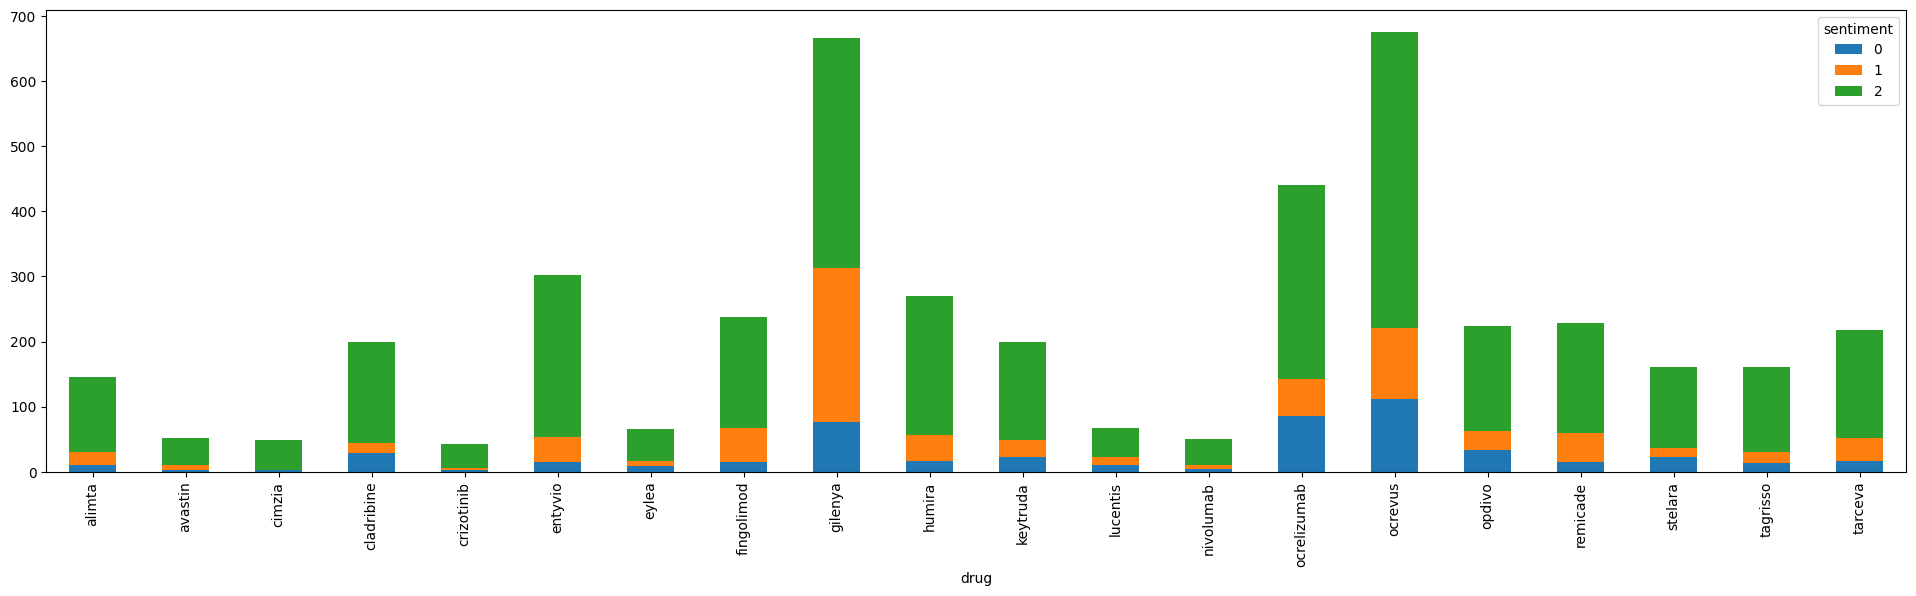

In [44]:
top_drugs = training_data['drug'].value_counts().head(20).index

training_data[training_data['drug'].isin(top_drugs)] \
.groupby(['drug','sentiment']) \
.size() \
.unstack() \
.fillna(0) \
.plot(kind='bar', stacked=True, figsize=(24,6))

<Axes: xlabel='drug'>

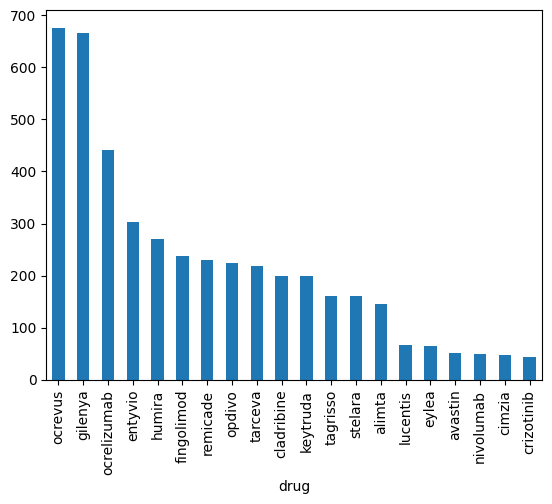

In [47]:
training_data['drug'].value_counts().head(20).plot(kind='bar')

In [48]:
from collections import Counter

all_words = " ".join(training_data['text']).split()
Counter(all_words).most_common(20)

[('the', 61123),
 ('of', 44248),
 ('to', 43476),
 ('and', 43014),
 ('a', 29922),
 ('in', 29153),
 ('I', 24562),
 ('for', 20700),
 ('is', 19172),
 ('with', 18878),
 ('that', 16090),
 ('or', 13162),
 ('on', 12287),
 ('have', 10863),
 ('was', 10141),
 ('be', 9891),
 ('it', 9480),
 ('you', 9445),
 ('are', 9397),
 ('my', 9185)]

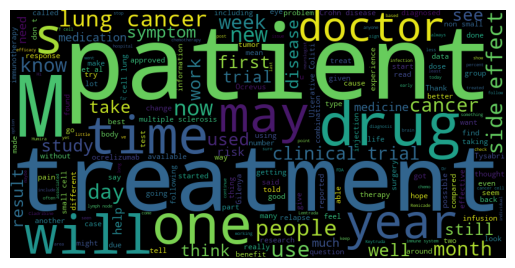

In [50]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(training_data['text'])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

# observation

1. Dataset Size

The training dataset contains 5,279 observations, each representing a user comment associated with a specific drug and its corresponding sentiment label.

Implication:
This dataset size is relatively small for deep learning models, which suggests that traditional machine learning algorithms may perform well.

2. Number of Unique Drugs

There are 102 unique drugs present in the training dataset.

Implication:
This indicates that the dataset covers a wide range of medications, and sentiment patterns may vary across different drugs.

3. Imbalanced Sentiment Distribution

The sentiment column shows a class imbalance, where one sentiment class appears significantly more frequently than the others.

Implication:
use stritify when splitting data
Class imbalance may affect model performance, so evaluation metrics such as F1-score will be important when comparing models.


4. Neutral Sentiment Dominates

A large proportion of the comments express neutral sentiment toward the drugs.

Implication:
The model may become biased toward predicting the neutral class if class imbalance is not considered during training.

5. Drug Frequency Distribution

The drug "Ocrevus" appears most frequently in the dataset, making it the most discussed medication in the training data.

Implication:
Certain drugs may dominate the dataset, which could influence model learning if not properly considered.

In [1]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

In [2]:
#loading the datasets
training_path = r'C:\\Users\\GIGABYTE\\Desktop\\drug-sentiment-analysis\\data\\raw\\train_F3WbcTw_1icmK82.csv'
test_path = r'C:\\Users\\GIGABYTE\\Desktop\\drug-sentiment-analysis\\data\\raw\\test_tOlRoBf_VeRQtHl.csv'
training_data = pd.read_csv(training_path)
test_data = pd.read_csv(test_path)

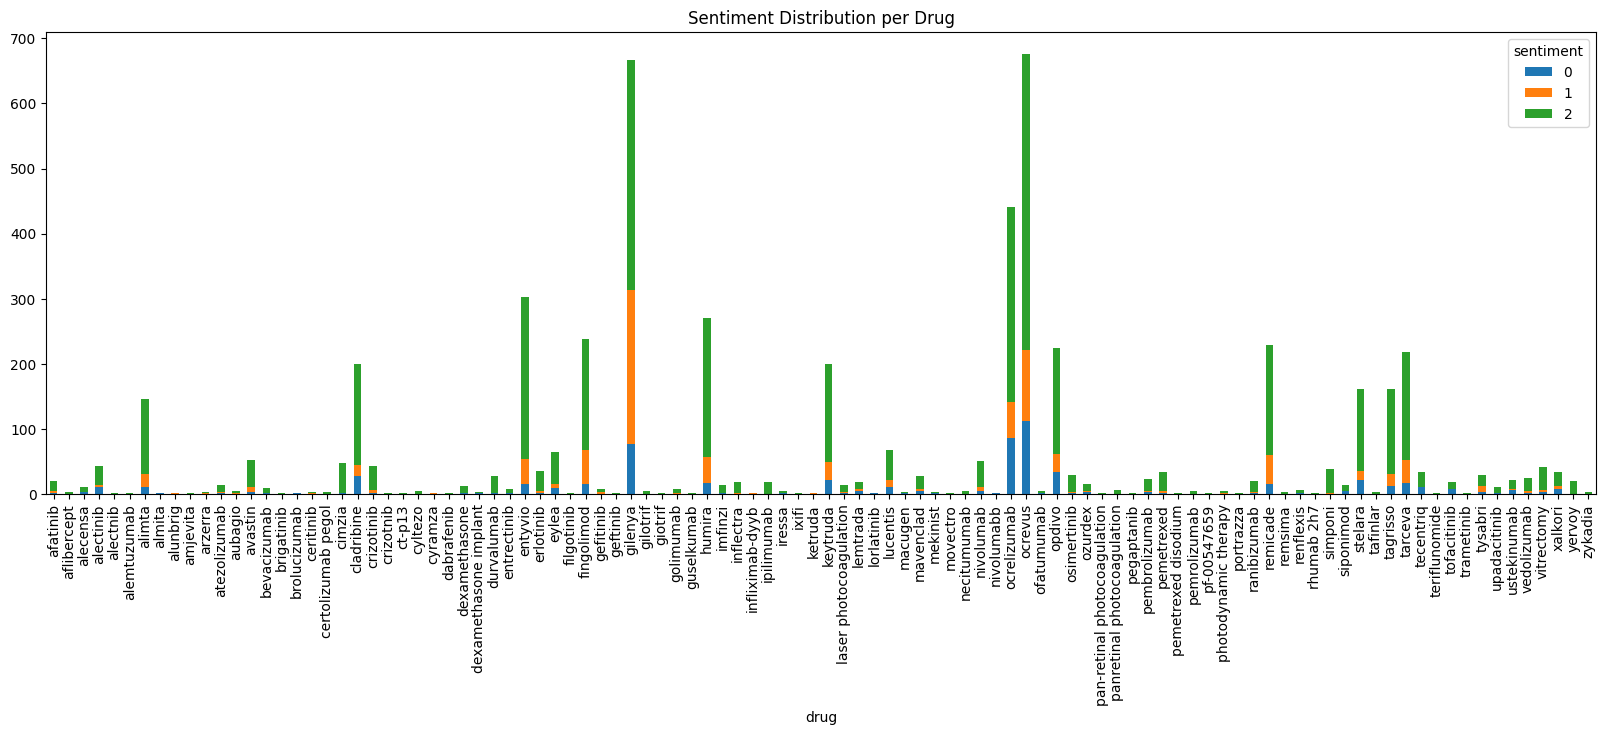

In [17]:
#display sentiment distribution per drug
training_data.groupby(['drug','sentiment']).size().unstack().fillna(0).plot(
    kind='bar',
    stacked=True,
    figsize=(20,6)
)
plt.title("Sentiment Distribution per Drug")
plt.show()

In [9]:
training_data[training_data["drug"] == 'almita']['text'].iloc[0]

'Thank you Janine. Once diagnosed back in Jan/16 she underwent 6 carbo/almita cycles with good results. Next she was put on maintenance treatment with almita but progressed after 2 cycles. She then went on afatinib. Once the tagrisso failed, she was put on carbo/taxol, however the side effects were very harsh so we then opted for Opdivo (I know that immunotherapy usually doesn’t bode well for EGFR, however, with her other mutations, KRAS included, her mutation load is high enough which may indicate a good response). I understand that chemo is probably the safest way to go in terms of getting a good response fast, is there something else compatible with almita (efficacy, side effects), as getting back to taxol would probably be difficult for her, thank you so much for helping, Ilan, p.s. is there any sort of radiation treatment option for liver mets, they are numerous, but maybe we can target the main ones, thanks'

In [18]:
training_data[training_data["drug"] == 'alimta']['text'].iloc[0]

'“Live in the Light of My Presence, and your light will shine brightly into the lives of others.” — Sarah Young from Jesus Calling   OK – it’s not the March Madness you sports fans care about … but it’s my personal March Madness, and it has definitely begun!!  Getting March Off the Ground  The month kicked off on March 2 with a CT scan in the morning and chemo in the afternoon. In the midst of recovering, on Sunday, March 4, Tim and I flew to Denver. Tim had a conference there (SWANApalooza, if you want to know 🙂 ), so I tagged along for a few days — the perfect opportunity to meet Dr. Camidge. (More on that below!). I am not a seasoned traveler and stupidly carried heavy stuff on the plane (and across the airport in a mad rush coming home), so I learned something from that experience for sure! On Monday, Dr. Kim called us to give us the results of the CT scan. His exact words were “stable, stable, stable!” (YAY!) So that means I keep on keeping on with the Alimta (chemo) every four we

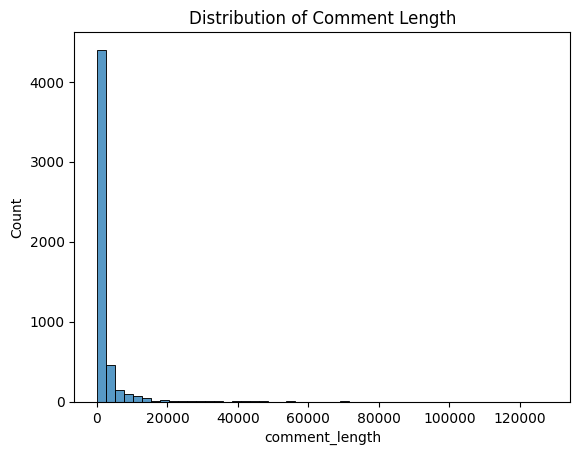

In [19]:
#distribution of comment length
training_data['comment_length'] = training_data['text'].apply(len)
sns.histplot(training_data['comment_length'], bins=50)
plt.title("Distribution of Comment Length")
plt.show()

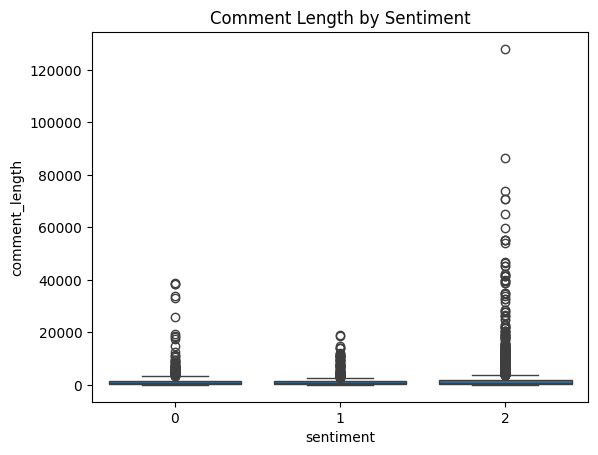

In [ ]:
#comment length by sentiment
sns.boxplot(x='sentiment', y='comment_length', data=training_data)
plt.title("Comment Length by Sentiment")
plt.show()

In [ ]:
#finding the most common words
from collections import Counter

words = " ".join(training_data['text']).split()
Counter(words).most_common(20)

[('the', 61123),
 ('of', 44248),
 ('to', 43476),
 ('and', 43014),
 ('a', 29922),
 ('in', 29153),
 ('I', 24562),
 ('for', 20700),
 ('is', 19172),
 ('with', 18878),
 ('that', 16090),
 ('or', 13162),
 ('on', 12287),
 ('have', 10863),
 ('was', 10141),
 ('be', 9891),
 ('it', 9480),
 ('you', 9445),
 ('are', 9397),
 ('my', 9185)]

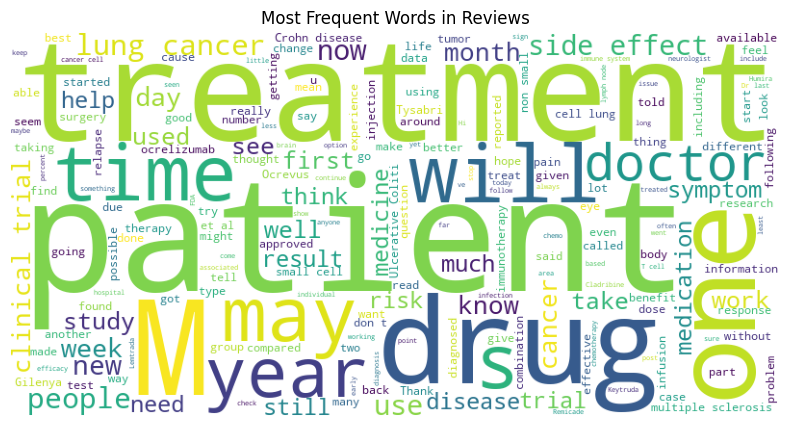

In [ ]:
#ploting word cloud for the most common words
from wordcloud import WordCloud

text = " ".join(training_data['text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Most Frequent Words in Reviews")
plt.show()

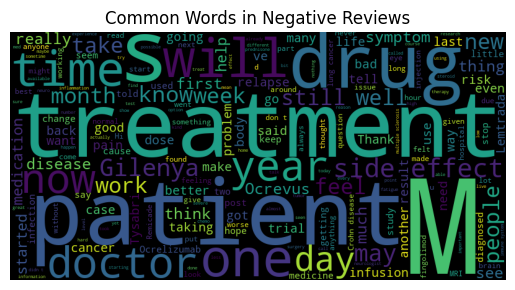

In [ ]:
#ploting word cloud for the most common words in negative sentiment
negative_text = " ".join(training_data[training_data['sentiment']==1]['text'])

wordcloud = WordCloud(width=800, height=400).generate(negative_text)

plt.imshow(wordcloud)
plt.axis('off')
plt.title("Common Words in Negative Reviews")
plt.show()

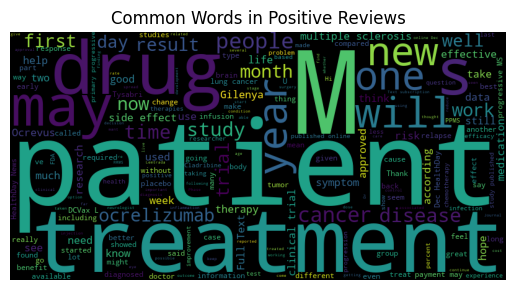

In [ ]:
#ploting word cloud for the most common words in positive sentiment
positive_text = " ".join(training_data[training_data['sentiment']==0]['text'])

wordcloud = WordCloud(width=800, height=400).generate(positive_text)

plt.imshow(wordcloud)
plt.axis('off')
plt.title("Common Words in Positive Reviews")
plt.show()

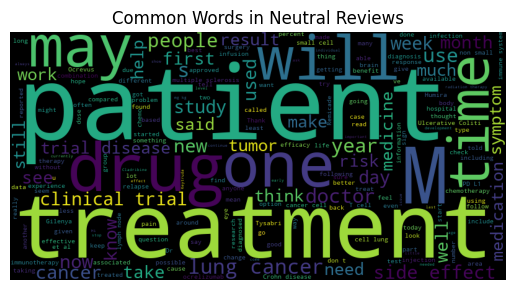

In [ ]:
#ploting word cloud for the most common words in neutral sentiment
neutral_text = " ".join(training_data[training_data['sentiment']==2]['text'])

wordcloud = WordCloud(width=800, height=400).generate(neutral_text)

plt.imshow(wordcloud)
plt.axis('off')
plt.title("Common Words in Neutral Reviews")
plt.show()

# Observation
1. Presence of Special Characters in the Text

The comments in the text column contain various special characters such as punctuation marks, symbols, and irregular formatting. These characters do not contribute meaningful information for sentiment classification and may introduce noise into the model.

Implication:
These characters will be removed during the text preprocessing stage to improve the quality of the textual data.

2. Inconsistent Drug Name Spellings

Some drug names appear to be misspelled both in the drug column and within the text column. These inconsistencies may cause the same drug to be treated as multiple different entities.

Implication:
Drug names will be standardized during preprocessing to ensure that all references to the same drug are consistent across the dataset.

3. High Frequency of Stopwords

The most frequently occurring words in the dataset include common stopwords such as "the", "and", "to", and "is". These words occur frequently but typically carry little semantic meaning for sentiment analysis.

Implication:
Stopwords will be removed during preprocessing to reduce noise and improve model performance.

Optional 4th Observation (Very Good to Add)

If you noticed comment length variation:

4. Variation in Comment Length

The length of comments varies significantly across the dataset, with some reviews being very short while others are detailed descriptions of user experiences.

Implication:
This variation may influence the richness of information available for sentiment classification.

In [6]:
#import necessary libraries for text preprocessing
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [15]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\GIGABYTE\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\GIGABYTE\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\GIGABYTE\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\GIGABYTE\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [8]:
#loading the datasets
training_path = r'C:\\Users\\GIGABYTE\\Desktop\\drug-sentiment-analysis\\data\\raw\\train_F3WbcTw_1icmK82.csv'
test_path = r'C:\\Users\\GIGABYTE\\Desktop\\drug-sentiment-analysis\\data\\raw\\test_tOlRoBf_VeRQtHl.csv'
training_data = pd.read_csv(training_path)
test_data = pd.read_csv(test_path)

In [9]:
#mapping the wrongly splelled drug names
drug_corrections = {
    "panrentinal photocoagulation": "pan-retinal photocoagulation",
    "pan-rentinal photocoagulation": "pan-retinal photocoagulation",
    
    "nivolumabb": "nivolumab",
    
    "ketruda": "keytruda",
    
    "giotrif": "gilotrif",
    
    "crizontnib": "crizotinib",
    
    "almita": "alimta"
}

In [10]:
#text preprocessing fuction
def preprocess_text(text):
    #lowercase
    text = text.lower()

    #remove urls
    text = re.sub(r'http\S+/www\S+', '', text)

    #remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    #tokenization
    tokens = word_tokenize(text)

    #stop word removal
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t not in stop_words]

    #lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    #join tokens back to string
    text = " ".join(tokens)
    return text

In [11]:
#function to correct drug names in the text
def correct_drugs(text):
    for wrong, correct in drug_corrections.items():
        text = text.replace(wrong, correct)
    return text

In [12]:
#function to correct drug names in drug column
def correct_drug_col(drug):
    for wrong, correct in drug_corrections.items():
        drug = drug.replace(wrong, correct)
    return drug

In [ ]:
#apply preprocessing on training and test datasets
training_data["cleaned_text"] = training_data["text"].apply(preprocess_text)

test_data["cleaned_text"] = test_data["text"].apply(preprocess_text)

#correct drug names in drug column
training_data['clean_drug'] = training_data['drug'].apply(correct_drug_col)

test_data['clean_drug'] = test_data['drug'].apply(correct_drug_col)

In [18]:
training_data["cleaned_text"] = training_data["cleaned_text"].apply(correct_drugs)
test_data["cleaned_text"] = test_data["cleaned_text"].apply(correct_drugs)

In [21]:
training_data.text[0], training_data.cleaned_text[0]

('Autoimmune diseases tend to come in clusters. As for Gilenya – if you feel good, don’t think about it, it won’t change anything but waste your time and energy. I’m taking Tysabri and feel amazing, no symptoms (other than dodgy color vision, but I’ve had it since always, so, don’t know) and I don’t know if it will last a month, a year, a decade, ive just decided to enjoy the ride, no point in worrying.',
 'autoimmune disease tend come cluster gilenya feel good dont think wont change anything waste time energy im taking tysabri feel amazing symptom dodgy color vision ive since always dont know dont know last month year decade ive decided enjoy ride point worrying')

In [22]:
training_data[training_data["drug"] == 'almita']['text']

1209    Thank you Janine. Once diagnosed back in Jan/1...
1372    My husband is in a similar situation. His stor...
Name: text, dtype: object

In [26]:
training_data[training_data["clean_drug"] == 'almita']['text']

Series([], Name: text, dtype: object)

In [1]:
#import neessary libraries for feature engineering
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from scipy.sparse import csr_matrix,hstack
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import OneHotEncoder

In [2]:
#load the processed datasets
training = pd.read_csv(r'C:\Users\GIGABYTE\Desktop\drug-sentiment-analysis\data\processed\training_data.csv')
test = pd.read_csv(r'C:\Users\GIGABYTE\Desktop\drug-sentiment-analysis\data\processed\test_data.csv')

In [3]:
training.head()

,unique_hash,text,drug,sentiment,cleaned_text,clean_drug
0,2e180be4c9214c1f5ab51fd8cc32bc80c9f612e0,Autoimmune diseases tend to come in clusters. ...,gilenya,2,autoimmune disease tend come cluster gilenya f...,gilenya
1,9eba8f80e7e20f3a2f48685530748fbfa95943e4,I can completely understand why you’d want to ...,gilenya,2,completely understand youd want try result rep...,gilenya
2,fe809672251f6bd0d986e00380f48d047c7e7b76,Interesting that it only targets S1P-1/5 recep...,fingolimod,2,interesting target sp receptor rather like fin...,fingolimod
3,bd22104dfa9ec80db4099523e03fae7a52735eb6,"Very interesting, grand merci. Now I wonder wh...",ocrevus,2,interesting grand merci wonder lemtrada ocrevu...,ocrevus
4,b227688381f9b25e5b65109dd00f7f895e838249,"Hi everybody, My latest MRI results for Brain ...",gilenya,1,hi everybody latest mri result brain cervical ...,gilenya


In [4]:
# check number of unique words in the cleaned_text column
unique_words = set(" ".join(training['cleaned_text']).split())

print("Vocabulary size:", len(unique_words))

Vocabulary size: 40035


In [5]:
from collections import Counter

all_words = " ".join(training['cleaned_text']).split()

word_counts = Counter(all_words)

rare_words = [word for word, count in word_counts.items() if count == 1]

print("Rare words:", len(rare_words))

Rare words: 17396


# Observation

The dataset contains 40,035 unique words, out of which 17,396 words appear only once across all reviews. This indicates a high proportion of rare tokens, which is common in natural language datasets due to spelling variations, domain-specific terminology, and noise.

To reduce dimensionality and improve model generalization, rare words will be filtered during TF-IDF feature extraction using a minimum document frequency threshold (min_df).

Some drugs appeared very infrequently in the dataset, with certain drugs occurring only once. Such rare categories can introduce noise when using one-hot encoding because the model cannot learn reliable patterns from a single observation. To mitigate this, drugs appearing fewer than a specified threshold were grouped into an other_drug category before encoding.

In [6]:
# vectorizer
tfidf = TfidfVectorizer(
    max_features=6000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.9
)

In [7]:
# checking rare drugs 
drug_counts = training['clean_drug'].value_counts()

rare_drugs = drug_counts[drug_counts < 5].index

In [8]:
rare_drugs

Index(['aubagio', 'photodynamic therapy', 'cyltezo', 'necitumumab', 'mekinist',
       'dexamethasone implant', 'remsima', 'certolizumab pegol', 'aflibercept',
       'macugen', 'arzerra', 'zykadia', 'tafinlar', 'ceritinib', 'ixifi',
       'brolucizumab', 'amjevita', 'teriflunomide', 'trametinib', 'lorlatinib',
       'dabrafenib', 'pan-retinal photocoagulation', 'infliximab-dyyb',
       'geftinib', 'pf-00547659', 'alunbrig', 'pemetrexed disodium',
       'portrazza', 'movectro', 'brigatinib', 'pegaptanib', 'alemtuzumab',
       'rhumab 2h7', 'filgotinib', 'alectnib', 'ct-p13', 'guselkumab',
       'cyramza'],
      dtype='object', name='clean_drug')

In [9]:
# repalcing rare drugs with "other drugs"
training['clean_drug'] = training['clean_drug'].replace(rare_drugs, 'other_drug')
test['clean_drug'] = test['clean_drug'].replace(rare_drugs, 'other_drug')

In [10]:
#get only the needed columns for feature engineering
train = training[["cleaned_text", "clean_drug", "sentiment"]]
testing = test[["cleaned_text", "clean_drug"]]

In [11]:
# Drug mention feature
train['drug_in_text'] = train.apply(
    lambda x: 1 if x['clean_drug'] in x['cleaned_text'] else 0,
    axis=1

)

testing['drug_in_text'] = testing.apply(
    lambda x: 1 if x['clean_drug'] in x['cleaned_text'] else 0,
    axis=1
)

C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_32428\1484315527.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['drug_in_text'] = train.apply(
C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_32428\1484315527.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testing['drug_in_text'] = testing.apply(


In [ ]:
# defining list of positive and negative words for feature enginnering
positive_words = [
    "worked","effective","great","excellent","relief",
    "helped","improved","better","amazing","perfect", "improvement"
    "recommended","success","good","love","progress","breakthrough",
    "promising", "best", "hope", "positive", "fantastic", "benefit"
]

negative_words = [
    "pain","nausea","vomit","vomiting","dizziness",
    "fatigue","rash","headache","diarrhea","cramps",
    "terrible","awful","worse","bad","horrible", "failure",
    "miserable", "fail", "horrifying", "infection", "terrified" 'terrible',
    "coughing", "insane"
]

In [13]:
train[train['sentiment'] == 1]['cleaned_text'].iloc[10]

'daughter tested ro positive nsclc taking crizotinib week recent scan ct bone show slight progression liver possible new spot bone spine rib cancer lung node appears stable even smaller blood work show high ldh low albumin reason believe crizotinib effective possible ro detection false positive testing performed paraffin embedded biopsy tissue fluorescence situ hybridization cell positive ro gene rearrangement topic modified year month ago fanos topic modified year month ago fanos topic modified year month ago fanos topic modified year month ago fanos'

In [ ]:
# function to count positive words
def positive_score(text):
    words = text.split()
    return sum(word in positive_words for word in words)

train['positive_score'] = train['cleaned_text'].apply(positive_score)
testing['positive_score'] = testing['cleaned_text'].apply(positive_score)

C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_32428\3954458097.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['positive_score'] = train['cleaned_text'].apply(positive_score)
C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_32428\3954458097.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testing['positive_score'] = testing['cleaned_text'].apply(positive_score)


In [ ]:
#function to count negative words
def negative_score(text):
    words = text.split()
    return sum(word in negative_words for word in words)

train['negative_score'] = train['cleaned_text'].apply(negative_score)
testing['negative_score'] = testing['cleaned_text'].apply(negative_score)

In [ ]:
# create sentiment strength features
train['sentiment_strength'] = train['positive_score'] - train['negative_score']
testing['sentiment_strength'] = testing['positive_score'] - testing['negative_score']

In [ ]:
#list of side effects
side_effect_words = [
    "side effect","caused","reaction","bleeding",
    "nausea","dizziness","headache", "fatigue", "diarrhea", "abdominal pain", "vomiting", "constipation", "dry mouth", "insomnia", 
    "rash", "itching", "swelling", "difficulty breathing", "chest pain", "irregular heartbeat", "seizures", 
    "muscle pain", "joint pain", "blurred vision", "hearing loss", "anxiety", "depression"
]


In [ ]:
# function to check for side effects
def side_effect_flag(text):
    return int(any(word in text for word in side_effect_words))

train['side_effect_flag'] = train['cleaned_text'].apply(side_effect_flag)
testing['side_effect_flag'] = testing['cleaned_text'].apply(side_effect_flag)

In [ ]:
#list of words indicating drug effectiveness
effect_words = [
    "worked","relief","effective","improved","helped"
]

In [ ]:
# fuc t0 check for drug effectiveness
def effectiveness_flag(text):
    return int(any(word in text for word in effect_words))

train['effect_flag'] = train['cleaned_text'].apply(effectiveness_flag)
testing['effect_flag'] = testing['cleaned_text'].apply(effectiveness_flag)

In [ ]:
#list of neutral words
neutral_words = [
    "started","taking","prescribed","week","month","day"
]

def neutral_score(text):
    words = text.split()
    return sum(word in neutral_words for word in words)

train['neutral_score'] = train['cleaned_text'].apply(neutral_score)
testing['neutral_score'] = testing['cleaned_text'].apply(neutral_score)

In [ ]:
#create pos to neg ratio feature
train['pos_neg_ratio'] = train['positive_score'] / (train['negative_score'] + 1)
testing['pos_neg_ratio'] = testing['positive_score'] / (testing['negative_score'] + 1)

In [ ]:
#checking the engineered features
train.head()

,cleaned_text,clean_drug,sentiment,drug_in_text,positive_score,negative_score,sentiment_strength,side_effect_flag,effect_flag,neutral_score,pos_neg_ratio
0,autoimmune disease tend come cluster gilenya f...,gilenya,2,1,2,0,2,0,0,2,2.0
1,completely understand youd want try result rep...,gilenya,2,1,3,0,3,0,1,0,3.0
2,interesting target sp receptor rather like fin...,fingolimod,2,1,0,0,0,0,0,0,0.0
3,interesting grand merci wonder lemtrada ocrevu...,ocrevus,2,1,0,0,0,0,0,0,0.0
4,hi everybody latest mri result brain cervical ...,gilenya,1,1,1,0,1,0,0,1,1.0


In [24]:
train.columns

Index(['cleaned_text', 'clean_drug', 'sentiment', 'drug_in_text',
       'positive_score', 'negative_score', 'sentiment_strength',
       'side_effect_flag', 'effect_flag', 'neutral_score', 'pos_neg_ratio'],
      dtype='object')

In [ ]:
#one hot encoding foor drugs
one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)


# define feature and target variables
X_text = train['cleaned_text']
X_drug = one_hot_encoder.fit_transform(train[["clean_drug"]])
y = train['sentiment']

In [33]:
#vectorize the text data
X_tfidf = tfidf.fit_transform(X_text)

In [36]:
# convert one-hot encoding to sparese marix

X_drug_sparse = csr_matrix(X_drug)

In [ ]:
# combine the text and drug features

X = hstack([
    X_tfidf,
    X_drug_sparse,
    csr_matrix(train[['drug_in_text',
                      'positive_score',
                      'negative_score',
                      'sentiment_strength',
                      'side_effect_flag',
                      'effect_flag',
                      'neutral_score',
                      'pos_neg_ratio']].values)
])

In [38]:
X.shape

(5279, 6068)

In [39]:
y.shape

(5279,)

In [ ]:
# over sampling the minority class
ros = RandomOverSampler(
    sampling_strategy={0:1200, 1:1200}
)

X_over, y_over = ros.fit_resample(X, y)

In [ ]:
# undersampling the majority class
rus = RandomUnderSampler(
    sampling_strategy={2:2000}
)

X_resampled, y_resampled = rus.fit_resample(X_over, y_over)

In [42]:
X_resampled.shape

(4400, 6068)

In [43]:
X.shape

(5279, 6068)

In [44]:
#spliting the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

In [45]:
#feature engineering for the test dataset
testing_text = testing['cleaned_text']
testing_drug = one_hot_encoder.transform(testing[["clean_drug"]])


testing_tfidf = tfidf.transform(testing_text)
#testing_drug_encoded = one_hot_encoder.transform(testing_drug)
testing_drug_sparse = csr_matrix(testing_drug)
final_testing = hstack([testing_tfidf, testing_drug_sparse,csr_matrix(testing[['drug_in_text',
                      'positive_score',
                      'negative_score',
                      'sentiment_strength',
                      'side_effect_flag',
                      'effect_flag',
                      'neutral_score',
                      'pos_neg_ratio']].values)])

In [46]:
final_testing.shape

(2924, 6068)

In [47]:
X.shape

(5279, 6068)

In [49]:
import joblib

# Save training features and target
joblib.dump(X_train, r"C:\Users\GIGABYTE\Desktop\drug-sentiment-analysis\data\processed/X_train.pkl")
joblib.dump(X_val, r"C:\Users\GIGABYTE\Desktop\drug-sentiment-analysis\data\processed/X_val.pkl")
joblib.dump(y_train, r"C:\Users\GIGABYTE\Desktop\drug-sentiment-analysis\data\processed/y_train.pkl")
joblib.dump(y_val, r"C:\Users\GIGABYTE\Desktop\drug-sentiment-analysis\data\processed/y_val.pkl")

# Save test features
joblib.dump(final_testing, r"C:\Users\GIGABYTE\Desktop\drug-sentiment-analysis\data\processed/X_test.pkl")
joblib.dump(tfidf, r"C:\Users\GIGABYTE\Desktop\drug-sentiment-analysis\data\processed/tfidf_vectorizer.pkl")
#joblib.dump(X_drug_encoded.columns, r"C:\Users\GIGABYTE\Desktop\drug-sentiment-analysis\data\processed/drug_columns.pkl")

['C:\\Users\\GIGABYTE\\Desktop\\drug-sentiment-analysis\\data\\processed/tfidf_vectorizer.pkl']

In [1]:
# import libraries for model training and evaluation
import joblib
import numpy as mp
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score


In [2]:
#read in the processed data
X_train = joblib.load(r'C:\Users\GIGABYTE\Desktop\drug-sentiment-analysis\data\processed\X_train.pkl')
y_train = joblib.load(r'C:\Users\GIGABYTE\Desktop\drug-sentiment-analysis\data\processed\y_train.pkl')

X_test = joblib.load(r'C:\Users\GIGABYTE\Desktop\drug-sentiment-analysis\data\processed\X_val.pkl')
y_test = joblib.load(r'C:\Users\GIGABYTE\Desktop\drug-sentiment-analysis\data\processed\y_val.pkl')

In [3]:
# train and evaluate logistic regression model as baseline
lr = LogisticRegression(max_iter=100)

lr.fit(X_train, y_train)

c:\Users\GIGABYTE\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [4]:
#make predictiona on test set
predictions = lr.predict(X_test)

#print f1 score on test set
print(f"the f1 score for logistic regression on the test set is: {f1_score(y_test, predictions, average='macro')}")

the f1 score for logistic regression on the test set is: 0.5930483635966732


In [5]:
#f1 score on training set
print(f"The f1 score for logistic regression on the training set is: {f1_score(y_train, lr.predict(X_train), average='macro')}")

The f1 score for logistic regression on the training set is: 0.7116027125443153


In [6]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.64      0.47      0.54       240
           1       0.59      0.53      0.56       240
           2       0.61      0.75      0.68       400

    accuracy                           0.61       880
   macro avg       0.62      0.58      0.59       880
weighted avg       0.62      0.61      0.61       880



In [7]:
# train and evaluate decision tree model
dt = DecisionTreeClassifier(
    max_depth=20,
    random_state=42
)

dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [8]:
#make prediction on test set with decision tree
predictions_dt = dt.predict(X_test)

#print f1 score on test set
print(f"the f1 score for decision tree on the test set is: {f1_score(y_test, predictions_dt, average='macro')}")
print(f"The f1 score for decision tree on the training set is: {f1_score(y_train, dt.predict(X_train), average='macro')}")

the f1 score for decision tree on the test set is: 0.6338391290263241
The f1 score for decision tree on the training set is: 0.8471768635624207


In [9]:
print(classification_report(y_test, predictions_dt))

              precision    recall  f1-score   support

           0       0.55      0.77      0.64       240
           1       0.70      0.57      0.63       240
           2       0.68      0.59      0.63       400

    accuracy                           0.63       880
   macro avg       0.64      0.64      0.63       880
weighted avg       0.65      0.63      0.63       880



In [ ]:
# train random forest model
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=25,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",25
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [11]:
#make prediction on test set with random forest
predictions_rf = rf.predict(X_test)

#print f1 score on test set
print(f"the f1 score for random forest on the test set is: {f1_score(y_test, predictions_rf, average='macro')}")
print(f"The f1 score for random forest on the training set is: {f1_score(y_train, rf.predict(X_train), average='macro')}")


the f1 score for random forest on the test set is: 0.7322322451484325
The f1 score for random forest on the training set is: 0.9229690559212544


In [12]:
print(classification_report(y_test, predictions_dt))

              precision    recall  f1-score   support

           0       0.55      0.77      0.64       240
           1       0.70      0.57      0.63       240
           2       0.68      0.59      0.63       400

    accuracy                           0.63       880
   macro avg       0.64      0.64      0.63       880
weighted avg       0.65      0.63      0.63       880



In [13]:
# train and evaluate support vector machine model
svm = SVC()

svm.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [14]:
#make prediction on test set with support vector machine
predictions_svm = svm.predict(X_test)

#print f1 score on test set
print(f"the f1 score for support vector machine on the test set is: {f1_score(y_test, predictions_svm, average='macro')}")
print(f"The f1 score for support vector machine on the training set is: {f1_score(y_train, svm.predict(X_train), average='macro')}")


the f1 score for support vector machine on the test set is: 0.41740576498485193
The f1 score for support vector machine on the training set is: 0.4248719509003645


In [15]:
# train and evaluate Xgboost model
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [16]:
#make prediction on test set with Xgboost
predictions_xgb = xgb.predict(X_test)

#print f1 score on test set
print(f"the f1 score for Xgboost on the test set is: {f1_score(y_test, predictions_xgb, average='macro')}")
print(f"The f1 score for Xgboost on the training set is: {f1_score(y_train, xgb.predict(X_train), average='macro')}")


the f1 score for Xgboost on the test set is: 0.7497920595213582
The f1 score for Xgboost on the training set is: 1.0


In [ ]:
# train and evaluate logistic regression with cross validation
log_reg_cv = LogisticRegressionCV(
    cv=5,
    max_iter=1000,
    n_jobs=-1
)

log_reg_cv.fit(X_train, y_train)

c:\Users\GIGABYTE\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\GIGABYTE\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warn

,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass set

In [18]:
#make prediction on test set with Logistic Regression CV
predictions_lr_cv = log_reg_cv.predict(X_test)

#print f1 score on test set
print(f"the f1 score for Logistic Regression CV on the test set is: {f1_score(y_test, predictions_lr_cv, average='macro')}")
print(f"The f1 score for Logistic Regression CV on the training set is: {f1_score(y_train, log_reg_cv.predict(X_train), average='macro')}")


the f1 score for Logistic Regression CV on the test set is: 0.7376109072219701
The f1 score for Logistic Regression CV on the training set is: 0.998611254811264


In [19]:
# train and evaluate logistic regression model as baseline
lr2 = LogisticRegression(max_iter=100,
                         class_weight='balanced',
    C=2)

lr2.fit(X_train, y_train)

c:\Users\GIGABYTE\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",2
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [20]:
#make prediction on test set with Logistic Regression CV 2
predictions_lr2 = lr2.predict(X_test)

#print f1 score on test set
print(f"the f1 score for Logistic Regression CV 2 on the test set is: {f1_score(y_test, predictions_lr2, average='macro')}")
print(f"The f1 score for Logistic Regression CV 2 on the training set is: {f1_score(y_train, lr2.predict(X_train), average='macro')}")


the f1 score for Logistic Regression CV 2 on the test set is: 0.6134098179211165
The f1 score for Logistic Regression CV 2 on the training set is: 0.729689270487634


In [21]:
#tuning decision tree with random ssearch cv
dt_rs = DecisionTreeClassifier(random_state=42)

dt_params = {
    'max_depth': [10, 20, 30, 40, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}

dt_search = RandomizedSearchCV(
    dt_rs,
    dt_params,
    n_iter=20,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1,
    verbose=1
)

dt_search.fit(X_train, y_train)

best_dt = dt_search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [ ]:
# prediction an evaluation of the tuned decision tree model
from sklearn.metrics import f1_score

y_pred_dt_rs = best_dt.predict(X_test)

print("Tuned Decision Tree F1 on test:",
      f1_score(y_test, y_pred_dt_rs, average='macro'))

print("Tuned Decision Tree F1 on train:",
      f1_score(y_train, best_dt.predict(X_train), average='macro'))

Tuned Decision Tree F1 on test: 0.709298489192205
Tuned Decision Tree F1 on train: 1.0


In [23]:
# tuning random forest with random search cv


rf_rs = RandomForestClassifier(random_state=42)

rf_params = {
    'n_estimators': [200, 300, 400],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    rf_rs,
    rf_params,
    n_iter=20,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [24]:
#make prediction on test set with Random Forest Random Search
y_pred_rf_rs = best_rf.predict(X_test)

#print f1 score on test set
print(f"the f1 score for Random Forest Random Search on the test set is: {f1_score(y_test, y_pred_rf_rs, average='macro')}")
print(f"The f1 score for Random Forest Random Search on the training set is: {f1_score(y_train, best_rf.predict(X_train), average='macro')}")

the f1 score for Random Forest Random Search on the test set is: 0.7717761454325182
The f1 score for Random Forest Random Search on the training set is: 0.9991661442853766


In [25]:
# tuning support vector machine with random search cv
svm_rs = LinearSVC()

svm_params = {
    'C': [0.01, 0.1, 1, 5, 10, 20]
}

svm_search = RandomizedSearchCV(
    svm_rs,
    svm_params,
    n_iter=10,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1
)

svm_search.fit(X_train, y_train)

best_svm = svm_search.best_estimator_

c:\Users\GIGABYTE\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\GIGABYTE\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [26]:
#make prediction on test set with Support Vector Machine Random Search
y_pred_svc_rs = best_svm.predict(X_test)

#print f1 score on test set
print(f"the f1 score for Support Vector Machine Random Search on the test set is: {f1_score(y_test, y_pred_svc_rs, average='macro')}")
print(f"The f1 score for Support Vector Machine Random Search on the training set is: {f1_score(y_train, best_svm.predict(X_train), average='macro')}")

the f1 score for Support Vector Machine Random Search on the test set is: 0.7230218683362825
The f1 score for Support Vector Machine Random Search on the training set is: 0.9745916304793285


In [27]:
# tuning xgboost with random search cv
xgb_rs = XGBClassifier(random_state=42)

xgb_params = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1],
    'colsample_bytree': [0.7, 0.8, 1]
}

xgb_search = RandomizedSearchCV(
    xgb_rs,
    xgb_params,
    n_iter=20,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [28]:
#make prediction on test set with XGBoost Random Search
y_pred_xgb_rs = best_xgb.predict(X_test)

#print f1 score on test set
print(f"the f1 score for XGBoost Random Search on the test set is: {f1_score(y_test, y_pred_xgb_rs, average='macro')}")
print(f"The f1 score for XGBoost Random Search on the training set is: {f1_score(y_train, best_xgb.predict(X_train), average='macro')}")

the f1 score for XGBoost Random Search on the test set is: 0.7534195090813144
The f1 score for XGBoost Random Search on the training set is: 0.9961078431450252


# model evalution

the f1 score for logistic regression on the test set is: 0.5930483635966732
The f1 score for logistic regression on the training set is: 0.7116027125443153

the f1 score for decision tree on the test set is: 0.6338391290263241
The f1 score for decision tree on the training set is: 0.8471768635624207

the f1 score for random forest on the test set is: 0.7322322451484325
The f1 score for random forest on the training set is: 0.9229690559212544

the f1 score for support vector machine on the test set is: 0.41740576498485193
The f1 score for support vector machine on the training set is: 0.4248719509003645

the f1 score for Xgboost on the test set is: 0.7497920595213582
The f1 score for Xgboost on the training set is: 1.0

the f1 score for Logistic Regression CV on the test set is: 0.7376109072219701
The f1 score for Logistic Regression CV on the training set is: 0.998611254811264

the f1 score for Logistic Regression CV 2 on the test set is: 0.6134098179211165
The f1 score for Logistic Regression CV 2 on the training set is: 0.729689270487634

Tuned Decision Tree F1 on test: 0.709298489192205
Tuned Decision Tree F1 on train: 1.0

the f1 score for Random Forest Random Search on the test set is: 0.7717761454325182
The f1 score for Random Forest Random Search on the training set is: 0.9991661442853766

the f1 score for Support Vector Machine Random Search on the test set is: 0.7230218683362825
The f1 score for Support Vector Machine Random Search on the training set is: 0.9745916304793285

the f1 score for XGBoost Random Search on the test set is: 0.7534195090813144
The f1 score for XGBoost Random Search on the training set is: 0.9961078431450252


In [ ]:
# load the test set for final prediction
tt = joblib.load(r"C:\Users\GIGABYTE\Desktop\drug-sentiment-analysis\data\processed/X_test.pkl")

In [ ]:
# make final prediction with the best random forst model
import numpy as np
np.unique(best_rf.predict(tt), return_counts=True)

(array([0, 1, 2]), array([  66,  139, 2719]))

In [ ]:
# make final prediction with the best xgboost model
np.unique(best_xgb.predict(tt), return_counts=True)

(array([0, 1, 2]), array([ 274,  433, 2217]))

In [44]:
print(classification_report(y_test, y_pred_rf_rs))

              precision    recall  f1-score   support

           0       0.98      0.70      0.81       240
           1       0.89      0.58      0.70       240
           2       0.69      0.95      0.80       400

    accuracy                           0.78       880
   macro avg       0.85      0.74      0.77       880
weighted avg       0.82      0.78      0.78       880



In [45]:
print(classification_report(y_test, y_pred_xgb_rs))

              precision    recall  f1-score   support

           0       0.82      0.74      0.78       240
           1       0.74      0.69      0.71       240
           2       0.74      0.81      0.77       400

    accuracy                           0.76       880
   macro avg       0.76      0.75      0.75       880
weighted avg       0.76      0.76      0.76       880



# Best classical classifcation 
the best model so far  is the *best_rf*

In [47]:
joblib.dump(best_rf, r"C:\Users\GIGABYTE\Desktop\drug-sentiment-analysis\model\best_rf.joblib")

['C:\\Users\\GIGABYTE\\Desktop\\drug-sentiment-analysis\\model\\best_rf.joblib']

# final prection
1. load text csv
2. load prepeocess text data
3. load model
4. make prediction
5. convert prediction to csv with header sentiment_prediction
6. merge csv prediction with text csv
7. save predcition

In [1]:
# import libraries
import joblib
import numpy as np
import pandas as pd


In [2]:
#load text cvs, processed test and model
test_df = pd.read_csv(r"C:\Users\GIGABYTE\Desktop\drug-sentiment-analysis\data\processed\test_data.csv")
X_test = joblib.load(r"C:\Users\GIGABYTE\Desktop\drug-sentiment-analysis\data\processed\X_test.pkl")
model = joblib.load(r"C:\Users\GIGABYTE\Desktop\drug-sentiment-analysis\model\best_rf.joblib")

In [ ]:
#making prediction
predictions = model.predict(X_test)

In [4]:
# convert predicgtions csv
submission_df = pd.DataFrame({
    "unique_hash" : test_df["unique_hash"],
    "predicted_sentiment" : predictions
})


In [5]:
submission_df.head()

,unique_hash,predicted_sentiment
0,9e9a8166b84114aca147bf409f6f956635034c08,2
1,e747e6822c867571afe7b907b51f0f2ca67b0e1a,2
2,50b6d851bcff4f35afe354937949e9948975adf7,2
3,7f82ec2176ae6ab0b5d20b5ffc767ac829f384ae,2
4,8b37d169dee5bdae27060949242fb54feb6a7f7f,2


In [6]:
#concatinate submission_df and test_df on unique_hash
final_df = pd.merge(test_df, submission_df, on="unique_hash", how="left")
final_df.head()

,unique_hash,text,drug,cleaned_text,clean_drug,predicted_sentiment
0,9e9a8166b84114aca147bf409f6f956635034c08,"256 (previously stable on natalizumab), with 5...",fingolimod,previously stable natalizumab switching fingol...,fingolimod,2
1,e747e6822c867571afe7b907b51f0f2ca67b0e1a,On fingolimod and have been since December 201...,fingolimod,fingolimod since december way describe better ...,fingolimod,2
2,50b6d851bcff4f35afe354937949e9948975adf7,Apparently it's shingles! :-/ I do have a few ...,humira,apparently shingle red spot left breast appear...,humira,2
3,7f82ec2176ae6ab0b5d20b5ffc767ac829f384ae,If the Docetaxel doing once a week x3 weeks th...,tagrisso,docetaxel week x week week claim less harsh ef...,tagrisso,2
4,8b37d169dee5bdae27060949242fb54feb6a7f7f,"CC, Stelara worked in a matter of days for me....",stelara,cc stelara worked matter day gi willing jump h...,stelara,2


In [10]:
final_df[final_df["predicted_sentiment"] == 1].head()

,unique_hash,cleaned_text,clean_drug,predicted_sentiment
17,245536722a649761b30a740031040a937d8b3e0e,hello guy hope well didnt know post topic excu...,gilenya,1
21,4c8c81babeb983eb8b420a0f6d49b7eb0e230c8b,thanks clo dunno much longer go like ive excru...,entyvio,1
49,a897b32296fbaef1a724f68c994dddd23d7bee9e,thankyou much md antijcv treatment market many...,gilenya,1
60,5223cdaa8d259f7232db72bd5b91a708567ed855,second go round avonex long story first time a...,gilenya,1
68,eeed9a8e13ac71f4bf74f727ee1944bfc6b59411,waynexxl glad fine coming gilenya one drug rea...,gilenya,1


In [9]:
final_df = final_df[["unique_hash", "cleaned_text", "clean_drug", "predicted_sentiment"]]

In [11]:
#save final_df to csv and submission_df to csv
final_df.to_csv(r"C:\Users\GIGABYTE\Desktop\drug-sentiment-analysis\predictions\final_predictions.csv", index=False)

submission_df.to_csv(r"C:\Users\GIGABYTE\Desktop\drug-sentiment-analysis\predictions\submission_predictions.csv", index=False)
